# GSAT Explainer for MNIST (Vanilla GIN)


In [1]:
import os
import sys
import random
import time
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool
from sklearn.metrics import roc_auc_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE =", DEVICE)

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "bcosgnn").is_dir():
            return p
    raise RuntimeError("Could not locate repo root (pyproject.toml + bcosgnn/).")

repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))
print("Repo root added:", repo_root)


/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE = cpu
Repo root added: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn


In [2]:
def _augment_with_normalized_pos(dataset):
    augmented = []
    for data in dataset:
        d = data.clone()
        pos = d.pos.float()
        pos_min = pos.min(dim=0).values
        pos_max = pos.max(dim=0).values
        denom = (pos_max - pos_min).clamp(min=1e-8)
        pos_norm = (pos - pos_min) / denom
        d.x = torch.cat([d.x.float(), pos_norm], dim=-1)
        augmented.append(d)
    return augmented

def load_and_split_data(batch_size=64, add_pos_features=True):
    print("Loading preprocessed sparsified .pt splits...")
    split_root = Path("/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits")
    
    if not split_root.exists():
        raise FileNotFoundError(f"Could not find saved sparsified split files at {split_root}.")

    train_dataset = torch.load(split_root / 'train_sparsified.pt', map_location='cpu', weights_only=False)
    val_dataset = torch.load(split_root / 'val_sparsified.pt', map_location='cpu', weights_only=False)
    test_dataset = torch.load(split_root / 'test_sparsified.pt', map_location='cpu', weights_only=False)

    # Balance test_dataset to 1000 datapoints (100 per class)
    class_counts = {i: 0 for i in range(10)}
    balanced_test = []
    for data in test_dataset:
        label = int(data.y.item())
        if class_counts.get(label, 0) < 100:
            balanced_test.append(data)
            class_counts[label] = class_counts.get(label, 0) + 1
    test_dataset = balanced_test

    if add_pos_features:
        train_dataset = _augment_with_normalized_pos(train_dataset)
        val_dataset = _augment_with_normalized_pos(val_dataset)
        test_dataset = _augment_with_normalized_pos(test_dataset)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    all_labels = torch.tensor([int(d.y.item()) for d in train_dataset + val_dataset + test_dataset])
    num_classes = int(all_labels.unique().numel())
    num_node_features = int(train_dataset[0].num_node_features)
    avg_train_edges = float(np.mean([int(d.edge_index.size(1)) for d in train_dataset[:1000]]))

    dataset_info = {
        'num_node_features': num_node_features,
        'num_classes': num_classes,
    }

    print(f"Using split directory: {split_root}")
    print(f"Loaded splits. Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
    print(f"Avg train edges: {avg_train_edges:.2f}")
    print(f"Node features: {num_node_features} (pos features added: {add_pos_features})")

    return train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader, dataset_info

BATCH_SIZE = 128
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader, dataset_info = load_and_split_data(batch_size=BATCH_SIZE)

Loading preprocessed sparsified .pt splits...
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 1000
Avg train edges: 66.31
Node features: 3 (pos features added: True)
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 1000
Avg train edges: 66.31
Node features: 3 (pos features added: True)


In [3]:
class MaskableGINConv(MessagePassing):
    def __init__(self, nn_mlp, train_eps=False):
        super().__init__(aggr='add')
        self.nn = nn_mlp
        self.initial_eps = 0.0
        if train_eps:
            self.initial_eps = nn.Parameter(torch.Tensor([0.0]))
            
    def forward(self, x, edge_index, edge_weight=None):
        out = self.propagate(edge_index, x=x, edge_weight=edge_weight)
        x_r = x[1] if isinstance(x, tuple) else x
        out = out + (1 + self.initial_eps) * x_r
        return self.nn(out)

    def message(self, x_j, edge_weight):
        msg = x_j
        if edge_weight is not None:
            msg = msg * edge_weight.view(-1, 1)
        return msg

class VanillaGINBackbone(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=4):
        super().__init__()
        self.node_emb = nn.Linear(in_channels, hidden_channels)
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_channels, 2 * hidden_channels),
                nn.BatchNorm1d(2 * hidden_channels),
                nn.ReLU(),
                nn.Linear(2 * hidden_channels, hidden_channels)
            )
            self.convs.append(MaskableGINConv(nn_mlp=mlp, train_eps=True))
        self.fc1 = nn.Linear(hidden_channels, hidden_channels // 2)
        self.fc2 = nn.Linear(hidden_channels // 2, out_channels)

    def forward(self, x, edge_index, edge_weight=None, batch=None):
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        x = self.node_emb(x)
        for conv in self.convs:
            x = conv(x, edge_index, edge_weight=edge_weight)
            x = F.relu(x)
        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.fc2(x)
        return x

class GSAT(nn.Module):
    def __init__(self, backbone, in_channels, hidden_channels, temperature=1.0):
        super().__init__()
        self.backbone = backbone
        self.temperature = temperature
        self.att_mlp = nn.Sequential(
            nn.Linear(in_channels * 2, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, 1),
        )
        for m in self.att_mlp.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)

    def get_mask(self, x, edge_index, training=True):
        row, col = edge_index
        edge_rep = torch.cat([x[row], x[col]], dim=-1)
        edge_logits = self.att_mlp(edge_rep).view(-1)
        if training:
            u = torch.rand_like(edge_logits)
            noise = torch.log(u + 1e-8) - torch.log(1 - u + 1e-8)
            mask = torch.sigmoid((edge_logits + noise) / self.temperature)
        else:
            mask = torch.sigmoid(edge_logits)
        return mask, edge_logits

    def forward(self, data, training=True):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        mask, mask_logits = self.get_mask(x, edge_index, training=training)
        pred_logits = self.backbone(x, edge_index, edge_weight=mask, batch=batch)
        return pred_logits, mask, mask_logits


In [4]:
def gsat_loss(pred_logits, ground_truth_labels, mask_logits, r=0.7, pred_loss_coef=1.0, info_loss_coef=1.0):
    criterion = nn.CrossEntropyLoss()
    pred_loss = criterion(pred_logits, ground_truth_labels)
    mask_probs = torch.sigmoid(mask_logits)
    prior_target = torch.full_like(mask_probs, 1.0 - r)
    info_loss = F.binary_cross_entropy(mask_probs, prior_target, reduction="mean")
    loss = (pred_loss_coef * pred_loss) + (info_loss_coef * info_loss)
    return loss, pred_loss, info_loss


## Multi-seed GSAT evaluation (mean ± std)

In [7]:
from sklearn.metrics import f1_score, roc_auc_score
import time
import numpy as np
import torch
import random
from copy import deepcopy

HIDDEN_DIM = 64
LR = 1e-3
EPOCHS = 100
EARLY_STOP_PATIENCE = 25
R_PRIOR = 0.7
INFO_LOSS_COEF = 3.0

def _sync_if_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def evaluate_results_for_model(model, loader, dataset):
    model.eval()
    node_aurocs = []
    node_jaccards = []
    node_f1s = []

    all_gt_labels = []
    all_pred_scores = []

    correct_graphs = 0
    total_graphs = 0
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data in loader:
            data = data.to(DEVICE)
            logits, mask, _ = model(data, training=False)
            pred_classes = logits.argmax(dim=1)
            
            all_preds.append(pred_classes.cpu())
            all_labels.append(data.y.cpu())
            
            correct_graphs += (pred_classes == data.y).sum().item()
            total_graphs += data.num_graphs

            if hasattr(data, 'node_mask') or hasattr(data, 'explanation_mask'):
                gt_mask = data.node_mask if hasattr(data, 'node_mask') else data.explanation_mask
                row, col = data.edge_index
                edge_gt = gt_mask[row].bool() & gt_mask[col].bool()
                all_gt_labels.extend(edge_gt.cpu().numpy())
                all_pred_scores.extend(mask.cpu().numpy())
                
    all_preds_np = torch.cat(all_preds).numpy()
    all_labels_np = torch.cat(all_labels).numpy()
    test_f1 = f1_score(all_labels_np, all_preds_np, average='macro')

    for data in dataset:
        data = data.to(DEVICE)
        if hasattr(data, 'node_mask'):
            gt_mask = data.node_mask.detach().cpu().numpy().astype(int)
        elif hasattr(data, 'explanation_mask'):
            gt_mask = data.explanation_mask.detach().cpu().numpy().astype(int)
        else:
            continue

        with torch.no_grad():
            _, mask, _ = model(data, training=False)

        row, col = data.edge_index
        mask_np = mask.cpu().numpy()
        node_scores = np.zeros(data.num_nodes)

        for i in range(len(row)):
            u, v = row[i], col[i]
            node_scores[u] = max(node_scores[u], mask_np[i])
            node_scores[v] = max(node_scores[v], mask_np[i])

        if node_scores.max() > node_scores.min():
            node_scores = (node_scores - node_scores.min()) / (node_scores.max() - node_scores.min())

        if len(np.unique(gt_mask)) > 1:
            node_aurocs.append(roc_auc_score(gt_mask, node_scores))

        k = int(gt_mask.sum())
        if k > 0:
            top_k_indices = np.argsort(node_scores)[-k:]
            pred_binary = np.zeros_like(node_scores)
            pred_binary[top_k_indices] = 1
            intersect = (pred_binary * gt_mask).sum()
            union = (pred_binary + gt_mask).clip(0, 1).sum()
            node_jaccards.append(intersect / (union + 1e-8))
            
            TP = intersect
            FP = pred_binary.sum() - TP
            FN = gt_mask.sum() - TP
            precision = TP / (TP + FP + 1e-8)
            recall = TP / (TP + FN + 1e-8)
            node_f1s.append(2 * (precision * recall) / (precision + recall + 1e-8))

    acc = correct_graphs / max(total_graphs, 1)
    global_edge_auc = roc_auc_score(all_gt_labels, all_pred_scores) if len(np.unique(all_gt_labels)) > 1 else float('nan')
    node_auc = float(np.mean(node_aurocs)) if node_aurocs else float('nan')
    node_jaccard = float(np.mean(node_jaccards)) if node_jaccards else float('nan')
    node_f1 = float(np.mean(node_f1s)) if node_f1s else float('nan')

    return acc, test_f1, global_edge_auc, node_auc, node_f1, node_jaccard

def benchmark_test_inference_total(model, test_loader):
    model.eval()
    _sync_if_cuda()
    t0 = time.perf_counter()
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(DEVICE)
            _ = model(batch, training=False)
    _sync_if_cuda()
    return time.perf_counter() - t0

def time_gsat_explain_per_graph_model(model, dataset, warmup: int = 2, max_graphs=None):
    model.eval()
    times_ms = []
    graphs = dataset[:max_graphs] if max_graphs is not None else dataset

    with torch.no_grad():
        for data in graphs[:warmup]:
            data = data.to(DEVICE)
            _ = model(data, training=False)

        for data in graphs:
            data = data.to(DEVICE)
            _sync_if_cuda()
            start = time.perf_counter()
            _ = model(data, training=False)
            _sync_if_cuda()
            end = time.perf_counter()
            times_ms.append((end - start) * 1000.0)

    arr = np.asarray(times_ms, dtype=float)
    mean_ms = float(arr.mean()) if arr.size else float('nan')
    median_ms = float(np.median(arr)) if arr.size else float('nan')
    p90_ms = float(np.percentile(arr, 90)) if arr.size else float('nan')
    total_s = float(arr.sum() / 1000.0) if arr.size else float('nan')
    graphs_per_s = float(1000.0 / mean_ms) if mean_ms > 0 else float('nan')

    return {
        'mean_ms': mean_ms,
        'median_ms': median_ms,
        'p90_ms': p90_ms,
        'total_s': total_s,
        'graphs_per_s': graphs_per_s,
        'n_graphs': int(arr.size),
    }

def train_gsat_one_seed(seed: int, epochs: int = EPOCHS, early_stop_patience: int = EARLY_STOP_PATIENCE):
    set_all_seeds(seed)

    backbone = VanillaGINBackbone(
        in_channels=dataset_info['num_node_features'],
        hidden_channels=HIDDEN_DIM,
        out_channels=dataset_info['num_classes'],
        num_layers=4,
    )
    model_seed = GSAT(
        backbone=backbone,
        in_channels=dataset_info['num_node_features'],
        hidden_channels=HIDDEN_DIM,
        temperature=1.0,
    ).to(DEVICE)

    optimizer_seed = torch.optim.Adam(model_seed.parameters(), lr=LR)
    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    _sync_if_cuda()
    train_start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model_seed.train()
        model_seed.temperature = 1.0 - (epoch / epochs) * (1.0 - 0.1)

        for batch in train_loader:
            batch = batch.to(DEVICE)
            optimizer_seed.zero_grad()
            logits, _, mask_logits = model_seed(batch, training=True)
            loss, _, _ = gsat_loss(
                logits, batch.y.view(-1).to(torch.long), mask_logits,
                r=R_PRIOR, pred_loss_coef=1.0, info_loss_coef=INFO_LOSS_COEF
            )
            loss.backward()
            optimizer_seed.step()

        model_seed.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(DEVICE)
                logits, _, _ = model_seed(batch, training=False)
                val_loss += criterion(logits, batch.y.view(-1).to(torch.long)).item()

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model_seed.state_dict().items()}
            epochs_no_improve = 0
            
        elif epoch > 1:
            epochs_no_improve += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:03d}/{epochs}: tau={model_seed.temperature:.2f} val_loss={val_loss/len(val_loader):.4f}")

        if epochs_no_improve >= early_stop_patience:
            print(f"  Early stopping at epoch {epoch}")
            break

    _sync_if_cuda()
    train_time_s = time.perf_counter() - train_start

    if best_state is not None:
        model_seed.load_state_dict(best_state)

    return model_seed, train_time_s

def run_multi_seed_experiment(
    seeds=(11, 22, 33, 44, 55),
    epochs=EPOCHS,
    early_stop_patience=EARLY_STOP_PATIENCE,
    timing_max_graphs=None,
 ):
    per_seed = []

    for seed in seeds:
        print(f'\n=== Seed {seed} ===')
        model_seed, train_time_s = train_gsat_one_seed(seed=seed, epochs=epochs, early_stop_patience=early_stop_patience)

        test_acc, test_f1, test_global_edge_auc, test_node_auc, test_node_f1, test_jaccard = evaluate_results_for_model(
            model_seed, test_loader, test_dataset
        )
        
        test_process_total_s = benchmark_test_inference_total(model_seed, test_loader)
        timing = time_gsat_explain_per_graph_model(model_seed, test_dataset, max_graphs=timing_max_graphs)

        row = {
            'seed': seed,
            'test_acc': test_acc,
            'test_f1': test_f1,
            'global_edge_auc': test_global_edge_auc,
            'node_auroc': test_node_auc,
            'node_f1': test_node_f1,
            'node_jaccard': test_jaccard,
            'train_time_s': train_time_s,
            'test_process_total_s': test_process_total_s,
            'explain_total_s': timing['total_s'],
            'mean_ms': timing['mean_ms'],
            'median_ms': timing['median_ms'],
            'p90_ms': timing['p90_ms'],
            'graphs_per_s': timing['graphs_per_s'],
            'n_graphs': timing['n_graphs'],
        }
        per_seed.append(row)
        print(
            f"Seed {seed} | Test Acc {test_acc:.4f} | Test F1 {test_f1:.4f} | Node AUROC {test_node_auc:.4f} | Node F1 {test_node_f1:.4f} | Node Jaccard {test_jaccard:.4f} | "
            f"Train {train_time_s:.2f}s | TestProc {test_process_total_s:.2f}s | "
            f"Explain {timing['total_s']:.2f}s ({timing['mean_ms']:.2f} ms/graph)"
        )

    print("\n" + "=" * 84)
    print("MULTI-SEED SUMMARY (mean ± std)")
    print("=" * 84)
    metrics = [
        "test_acc",
        "test_f1",
        "global_edge_auc",
        "node_auroc",
        "node_f1",
        "node_jaccard",
        "train_time_s",
        "test_process_total_s",
        "explain_total_s",
        "mean_ms",
        "median_ms",
        "p90_ms",
        "graphs_per_s",
    ]
    for metric in metrics:
        vals = np.array([row[metric] for row in per_seed], dtype=float)
        print(f"{metric:22s}: {vals.mean():.4f} ± {vals.std():.4f}")

    print("-" * 84)
    print(f"Total explanation time over all seeds    : {sum(row['explain_total_s'] for row in per_seed):.4f} s")
    print(f"Total test processing time over all seeds: {sum(row['test_process_total_s'] for row in per_seed):.4f} s")
    print(f"Total training time over all seeds       : {sum(row['train_time_s'] for row in per_seed):.4f} s")

    return per_seed

## Single-seed GSAT training (for visualization)

In [8]:
# Single-seed GSAT training (no multi-seed sweep)
GSAT_SEED = 11
GSAT_EPOCHS = EPOCHS
GSAT_PATIENCE = EARLY_STOP_PATIENCE

gsat_model, gsat_train_time_s = train_gsat_one_seed(
    seed=GSAT_SEED,
    epochs=GSAT_EPOCHS,
    early_stop_patience=GSAT_PATIENCE,
 )

test_acc, test_f1, test_global_edge_auc, test_node_auc, test_node_f1, test_jaccard = evaluate_results_for_model(
    gsat_model, test_loader, test_dataset
 )

print(
    f"GSAT (seed={GSAT_SEED}) | Test Acc {test_acc:.4f} | Test F1 {test_f1:.4f} | "
    f"Node AUROC {test_node_auc:.4f} | Node F1 {test_node_f1:.4f} | Node Jaccard {test_jaccard:.4f} | "
    f"Train {gsat_train_time_s:.2f}s"
 )

  Epoch 001/100: tau=0.99 val_loss=3.1334
  Epoch 005/100: tau=0.95 val_loss=0.8338
  Epoch 005/100: tau=0.95 val_loss=0.8338
  Epoch 010/100: tau=0.91 val_loss=0.7047
  Epoch 010/100: tau=0.91 val_loss=0.7047
  Epoch 015/100: tau=0.86 val_loss=0.5744
  Epoch 015/100: tau=0.86 val_loss=0.5744
  Epoch 020/100: tau=0.82 val_loss=0.7537
  Epoch 020/100: tau=0.82 val_loss=0.7537
  Epoch 025/100: tau=0.78 val_loss=0.4565
  Epoch 025/100: tau=0.78 val_loss=0.4565
  Epoch 030/100: tau=0.73 val_loss=0.4731
  Epoch 030/100: tau=0.73 val_loss=0.4731
  Epoch 035/100: tau=0.69 val_loss=0.5081
  Epoch 035/100: tau=0.69 val_loss=0.5081
  Epoch 040/100: tau=0.64 val_loss=0.5170
  Epoch 040/100: tau=0.64 val_loss=0.5170
  Epoch 045/100: tau=0.59 val_loss=0.4104
  Epoch 045/100: tau=0.59 val_loss=0.4104
  Epoch 050/100: tau=0.55 val_loss=0.4288
  Epoch 050/100: tau=0.55 val_loss=0.4288
  Epoch 055/100: tau=0.50 val_loss=0.4083
  Epoch 055/100: tau=0.50 val_loss=0.4083
  Epoch 060/100: tau=0.46 val_loss

## GSAT explanation figure (GT vs GSAT masks)

Saved GSAT explanation figure: GSAT_MNIST_Explanations.pdf


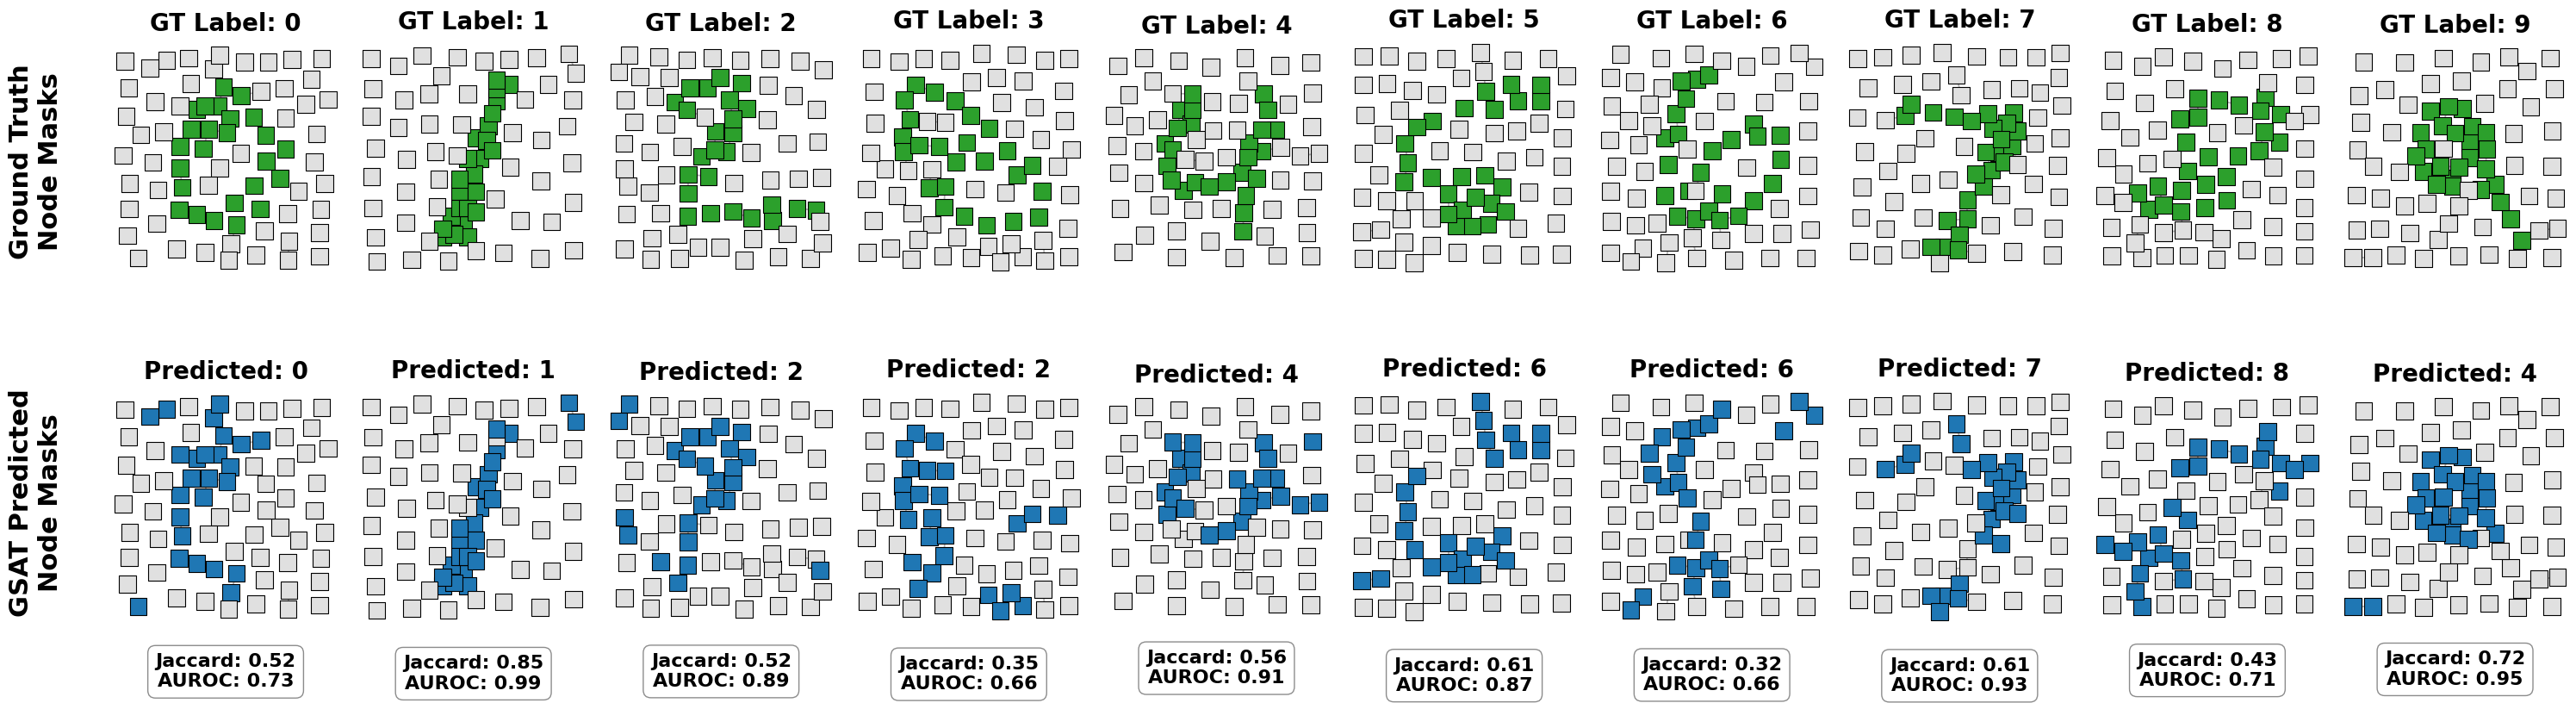

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

def get_gsat_node_scores(model, data):
    if not (hasattr(data, 'node_mask') or hasattr(data, 'explanation_mask')):
        raise ValueError("Ground-truth node mask not found on this sample.")
    gt_mask = data.node_mask if hasattr(data, 'node_mask') else data.explanation_mask
    gt_mask = gt_mask.detach().cpu().numpy().astype(int)

    model_device = next(model.parameters()).device
    data = data.clone().to(model_device)
    if not hasattr(data, 'batch') or data.batch is None:
        data.batch = torch.zeros(data.num_nodes, dtype=torch.long, device=model_device)

    model.eval()
    with torch.no_grad():
        logits, edge_mask, _ = model(data, training=False)
        pred_label = int(torch.argmax(logits, dim=-1).item())

    row, col = data.edge_index
    node_scores = torch.zeros(data.num_nodes, device=model_device)
    for i in range(edge_mask.numel()):
        u = row[i]
        v = col[i]
        score = edge_mask[i]
        if score > node_scores[u]:
            node_scores[u] = score
        if score > node_scores[v]:
            node_scores[v] = score

    return node_scores.detach().cpu().numpy(), gt_mask, pred_label

samples_by_class = {}
for idx in range(len(test_dataset)):
    data = test_dataset[idx]
    if not (hasattr(data, 'node_mask') or hasattr(data, 'explanation_mask')):
        continue
    label = int(data.y.item())
    if label not in samples_by_class:
        samples_by_class[label] = data.clone()
    if len(samples_by_class) == dataset_info['num_classes']:
        break

class_labels = sorted(samples_by_class.keys())
num_classes = len(class_labels)

fig, axes = plt.subplots(2, num_classes, figsize=(3 * num_classes, 9))
fig.subplots_adjust(top=0.88, bottom=0.12, left=0.04, right=0.99, wspace=0.1, hspace=0.45)

fig.text(0.01, 0.72, 'Ground Truth\nNode Masks', fontsize=22, fontweight='bold', va='center', ha='center', rotation=90)
fig.text(0.01, 0.28, 'GSAT Predicted\nNode Masks', fontsize=22, fontweight='bold', va='center', ha='center', rotation=90)

if num_classes == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for col_idx, class_label in enumerate(class_labels):
    graph_data = samples_by_class[class_label].clone()
    node_scores, gt_mask, pred_label = get_gsat_node_scores(gsat_model, graph_data)

    k = int(gt_mask.sum())
    pred_mask = np.zeros_like(gt_mask)
    if k > 0:
        top_k = np.argsort(node_scores)[-k:]
        pred_mask[top_k] = 1

    auc = float(roc_auc_score(gt_mask, node_scores)) if len(np.unique(gt_mask)) > 1 else float('nan')
    intersection = np.logical_and(pred_mask == 1, gt_mask == 1).sum()
    union = np.logical_or(pred_mask == 1, gt_mask == 1).sum()
    jaccard = float(intersection / union) if union > 0 else 0.0

    graph_plot = graph_data.to('cpu')
    x_coords = graph_plot.pos[:, 0].detach().cpu().numpy()
    y_coords = graph_plot.pos[:, 1].detach().cpu().numpy()
    row, col = graph_plot.edge_index

    ax_gt = axes[0, col_idx]
    ax_pred = axes[1, col_idx]

    for i in range(graph_plot.num_edges):
        s = graph_plot.pos[row[i]].detach().cpu().numpy()
        e = graph_plot.pos[col[i]].detach().cpu().numpy()
        ax_gt.plot([s[0], e[0]], [s[1], e[1]], color='gray', alpha=0.35, linewidth=1.2)
        ax_pred.plot([s[0], e[0]], [s[1], e[1]], color='gray', alpha=0.35, linewidth=1.2)

    gt_cmap = plt.cm.colors.ListedColormap(['#e0e0e0', '#2ca02c'])
    pred_cmap = plt.cm.colors.ListedColormap(['#e0e0e0', '#1f77b4'])

    ax_gt.scatter(
        x_coords, y_coords, c=gt_mask, cmap=gt_cmap,
        marker='s', s=200, edgecolor='black', linewidth=0.8, vmin=0, vmax=1, zorder=5
    )
    ax_gt.invert_yaxis()
    ax_gt.set_aspect('equal')
    ax_gt.axis('off')
    ax_gt.set_title(f'GT Label: {int(graph_plot.y.item())}', fontsize=20, fontweight='bold', pad=12)

    ax_pred.scatter(
        x_coords, y_coords, c=pred_mask, cmap=pred_cmap,
        marker='s', s=200, edgecolor='black', linewidth=0.8, vmin=0, vmax=1, zorder=5
    )
    ax_pred.invert_yaxis()
    ax_pred.set_aspect('equal')
    ax_pred.axis('off')
    ax_pred.set_title(f'Predicted: {pred_label}', fontsize=20, fontweight='bold', pad=12)
    ax_pred.text(
        0.5, -0.15, f'Jaccard: {jaccard:.2f}\nAUROC: {auc:.2f}',
        transform=ax_pred.transAxes, ha='center', va='top',
        fontsize=16, fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.4')
    )

output_filename = 'GSAT_MNIST_Explanations.pdf'
plt.savefig(output_filename, format='pdf', bbox_inches='tight', dpi=300)
print(f"Saved GSAT explanation figure: {output_filename}")
plt.show()

## BCos GIN + GT Mask Evaluation

In [10]:
import bcosgnn
import torch
import torch_geometric
import functools
import itertools
import operator
from pathlib import Path
from typing import Any
from torch_geometric.data import Dataset, download_url
from torch.utils.data import random_split
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from bcos.modules import BcosLinear, BcosSequential
from sklearn.model_selection import train_test_split
from torch.nn import BCEWithLogitsLoss
from torch_geometric.datasets import BA2MotifDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.nn.aggr import SumAggregation
from torch_geometric.utils import add_self_loops, degree
from torchmetrics import AUROC
from torchmetrics.classification import BinaryAccuracy
from tqdm import tqdm
import networkx as nx
import torch.nn.functional as F
from bcosgnn.explain import explain
import torch.nn as nn
from torch_geometric.nn import GINConv, global_mean_pool
from sklearn.metrics import f1_score, accuracy_score

In [13]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for data in tqdm(loader, desc="Training", leave=False):
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs

    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data in tqdm(loader, desc="Evaluating", leave=False):
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            loss = criterion(out, data.y)
            total_loss += loss.item() * data.num_graphs

            pred = torch.argmax(out, dim=1)
            all_preds.append(pred.cpu().numpy())
            all_labels.append(data.y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(np.concatenate(all_labels), np.concatenate(all_preds))
    f1 = f1_score(np.concatenate(all_labels), np.concatenate(all_preds), average='weighted')

    return avg_loss, acc, f1

In [18]:
from sklearn.metrics import roc_auc_score

class BcosGINConv(MessagePassing):
    def __init__(self, channels, b=2, max_out=1, eps=0.0, train_eps=False, **kwargs):
        kwargs.setdefault('aggr', 'add')
        super().__init__(**kwargs)
        self.transform = BcosSequential(
            *[
                BcosLinear(din, dout, b=b, max_out=max_out)
                for din, dout in zip(channels[:-1], channels[1:])
            ]
        )
        if train_eps:
            self.eps = torch.nn.Parameter(torch.tensor([eps], dtype=torch.float))
        else:
            self.register_buffer('eps', torch.tensor([eps], dtype=torch.float))

    def forward(self, x, edge_index):
        x_res = x
        out = self.propagate(edge_index, x=x)
        out = (1 + self.eps) * x_res + out
        return self.transform(out)

    def message(self, x_j):
        return x_j


class BCosGIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=4, b=2, max_out=1):
        super().__init__()
        self.lin_node = BcosLinear(in_channels, hidden_channels, b=b, max_out=max_out)
        self.convs = torch.nn.ModuleList(
            [BcosGINConv([hidden_channels, hidden_channels], b=b, max_out=max_out, train_eps=True) for _ in range(num_layers)]
        )
        self.agg = SumAggregation()
        self.readout = BcosSequential(
            BcosLinear(hidden_channels, hidden_channels, b=b, max_out=max_out),
            BcosLinear(hidden_channels, out_channels, b=b, max_out=max_out),
        )

    def forward(self, x, edge_index, batch):
        x = self.lin_node(x)
        for conv in self.convs:
            x = conv(x, edge_index)
        x = self.agg(x, batch)
        out = self.readout(x)
        return out


def train_bcos_gin(
    epochs=100,
    batch_size=64,
    lr=1e-3,
    hidden_channels=64,
    num_layers=4,
    use_scheduler=False,
    fixed_lr=5e-3,
    early_stopping=True,
    patience=15,
    min_delta=0.0,
 ):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')

    _, _, _, train_loader, val_loader, test_loader, dataset_info = load_and_split_data(
        batch_size=batch_size, add_pos_features=True
    )

    model = BCosGIN(
        in_channels=dataset_info['num_node_features'],
        hidden_channels=hidden_channels,
        out_channels=dataset_info['num_classes'],
        num_layers=num_layers,
        b=2,
        max_out=1,
    ).to(device)

    effective_lr = lr if use_scheduler else fixed_lr
    optimizer = torch.optim.Adam(model.parameters(), lr=effective_lr)
    criterion = nn.CrossEntropyLoss()
    scheduler = (
        torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
        if use_scheduler
        else None
    )

    best_val_loss = float('inf')
    best_state = None
    wait = 0

    print('Starting BCos GIN training...')
    print(
        f'Config -> epochs={epochs}, batch_size={batch_size}, hidden={hidden_channels}, layers={num_layers}, '
        f'use_scheduler={use_scheduler}, lr={effective_lr}, early_stopping={early_stopping}, patience={patience}'
    )

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, device)

        if scheduler is not None:
            scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        improved = val_loss < (best_val_loss - min_delta)
        if improved:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        print(
            f'[BCOS] Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, '
            f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}, LR: {current_lr:.6f}'
        )

        if early_stopping and wait >= patience:
            print(f'[BCOS] Early stopping at epoch {epoch} (no val loss improvement for {patience} epochs).')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_acc, test_f1 = evaluate(model, test_loader, criterion, device)
    print(f'[BCOS] Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}')

    return model, train_loader, val_loader, test_loader


def get_bcos_node_scores(model, data):
    model_device = next(model.parameters()).device
    data = data.to(model_device)
    batch = torch.zeros(data.x.size(0), dtype=torch.long, device=model_device)

    node_contrib = explain(model, data.x, data.edge_index, batch).detach()
    node_scores = node_contrib.abs().sum(dim=1).cpu().numpy()
    gt_mask = data.node_mask.detach().cpu().numpy().reshape(-1).astype(int)

    return node_scores, gt_mask


def evaluate_bcos_explanations(model, dataset, max_graphs=None):
    jaccards = []
    aurocs = []
    n = len(dataset) if max_graphs is None else min(len(dataset), max_graphs)

    for idx in range(n):
        data = dataset[idx].clone()
        if not hasattr(data, 'node_mask') or data.node_mask is None:
            continue

        scores, gt = get_bcos_node_scores(model, data)
        k = int(gt.sum())
        if k <= 0:
            continue

        top_k = np.argsort(scores)[-k:]
        pred = np.zeros_like(gt)
        pred[top_k] = 1

        intersection = np.logical_and(gt == 1, pred == 1).sum()
        union = np.logical_or(gt == 1, pred == 1).sum()
        jaccard = float(intersection / union) if union > 0 else 0.0
        jaccards.append(jaccard)

        if gt.min() != gt.max():
            aurocs.append(float(roc_auc_score(gt, scores)))

    mean_jacc = float(np.mean(jaccards)) if len(jaccards) else float('nan')
    mean_auroc = float(np.mean(aurocs)) if len(aurocs) else float('nan')

    print(f'[BCOS Explain] Graphs evaluated: {n}')
    print(f'[BCOS Explain] Mean Jaccard: {mean_jacc:.4f}')
    print(f'[BCOS Explain] Mean AUROC: {mean_auroc:.4f}')

    return {'jaccard': mean_jacc, 'auroc': mean_auroc, 'num_graphs': n}

In [19]:
# Run BCos-GIN with scheduler OFF and fixed LR, with early stopping
bcos_model, bcos_train_loader, bcos_val_loader, bcos_test_loader = train_bcos_gin(
    epochs=100,
    batch_size=64,
    lr=1e-3,
    hidden_channels=64,
    num_layers=4,
    use_scheduler=False,
    fixed_lr=5e-3,
    early_stopping=True,
    patience=15,
    min_delta=0.0,
 )

# Evaluate explanation quality on the entire test set
bcos_metrics = evaluate_bcos_explanations(
    bcos_model,
    bcos_test_loader.dataset,
    max_graphs=None,
 )

print('BCos explanation metrics:', bcos_metrics)

Using device: cpu
Loading preprocessed sparsified .pt splits...
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 1000
Avg train edges: 66.31
Node features: 3 (pos features added: True)
Starting BCos GIN training...
Config -> epochs=100, batch_size=64, hidden=64, layers=4, use_scheduler=False, lr=0.005, early_stopping=True, patience=15
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 1000
Avg train edges: 66.31
Node features: 3 (pos features added: True)
Starting BCos GIN training...
Config -> epochs=100, batch_size=64, hidden=64, layers=4, use_scheduler=False, lr=0.005, early_stopping=True, patience=15


[BCOS] Epoch 001, Train Loss: 2.0842, Val Loss: 2.0428, Val Acc: 0.2260, Val F1: 0.1746, LR: 0.005000


[BCOS] Epoch 002, Train Loss: 2.0504, Val Loss: 2.0135, Val Acc: 0.2392, Val F1: 0.1566, LR: 0.005000


[BCOS] Epoch 003, Train Loss: 2.0241, Val Loss: 2.0361, Val Acc: 0.2384, Val F1: 0.1677, LR: 0.005000


[BCOS] Epoch 004, Train Loss: 2.0070, Val Loss: 2.0155, Val Acc: 0.2552, Val F1: 0.1911, LR: 0.005000


...

[BCOS] Epoch 097, Train Loss: 0.4461, Val Loss: 0.5989, Val Acc: 0.8010, Val F1: 0.8007, LR: 0.005000


[BCOS] Epoch 098, Train Loss: 0.4447, Val Loss: 0.5827, Val Acc: 0.8108, Val F1: 0.8111, LR: 0.005000


[BCOS] Epoch 099, Train Loss: 0.4278, Val Loss: 0.5086, Val Acc: 0.8342, Val F1: 0.8342, LR: 0.005000


[BCOS] Epoch 100, Train Loss: 0.4329, Val Loss: 0.5383, Val Acc: 0.8268, Val F1: 0.8276, LR: 0.005000


[BCOS] Test Loss: 0.5554, Test Acc: 0.7980, Test F1: 0.7989
[BCOS Explain] Graphs evaluated: 1000
[BCOS Explain] Mean Jaccard: 0.8295
[BCOS Explain] Mean AUROC: 0.9675
BCos explanation metrics: {'jaccard': 0.8294833988456478, 'auroc': 0.9674967999999999, 'num_graphs': 1000}
[BCOS Explain] Graphs evaluated: 1000
[BCOS Explain] Mean Jaccard: 0.8295
[BCOS Explain] Mean AUROC: 0.9675
BCos explanation metrics: {'jaccard': 0.8294833988456478, 'auroc': 0.9674967999999999, 'num_graphs': 1000}


Checking MNIST Completeness: 100%|██████████| 500/500 [00:00<00:00, 863.10it/s]




B-cos MNIST Completeness Gap (MAE): 4.82e-07


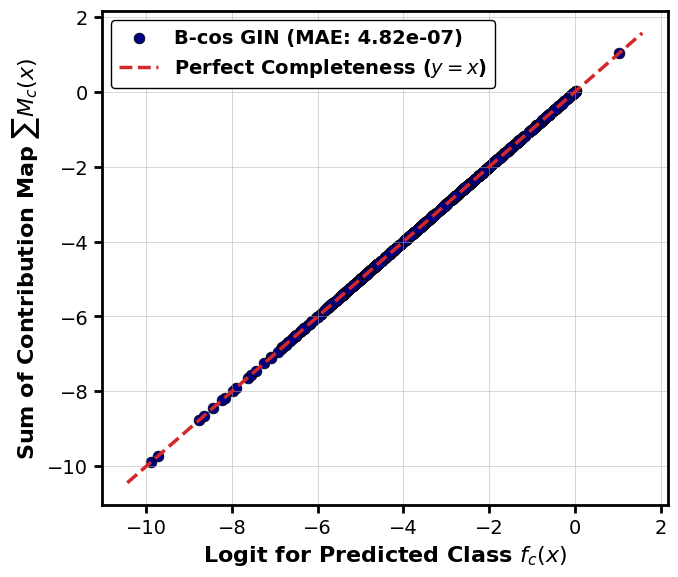

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm
from bcosgnn.explain import explain

# --- 1. Publication Quality Global Settings ---
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.labelweight': 'bold',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.figsize': (7, 6), 
    'axes.linewidth': 2.0,    
    'font.family': 'sans-serif' 
})

def run_mnist_completeness_check(dataset, model, device='cpu', max_samples=500):
    model.eval()
    
    bcos_logits = []
    bcos_contrib_sums = []

    # Iterate over the test set (limit to max_samples for speed)
    for i in tqdm(range(min(len(dataset), max_samples)), desc="Checking MNIST Completeness"):
        data = dataset[i].to(device)
        batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)
        
        # 1. Get Model Prediction (Logits for all 10 digit classes)
        with torch.no_grad():
            logits = model(data.x, data.edge_index, batch)
            
            # Find the winning digit class
            pred_class = int(logits.argmax(dim=-1).item())
            
            # Get the exact logit score for that winning class
            target_logit = logits[0, pred_class].item()
            
        # 2. Get B-cos Contributions for the predicted class
        # Note: explain() automatically uses the max logit class
        contrib = explain(
            model,
            data.x,
            data.edge_index,
            batch
        )
        
        # 3. Sum the RAW (signed) node contributions
        # The 'explain' function here returns a tensor of node contributions
        total_contrib_sum = contrib.sum().item()
        
        # Store for plotting
        bcos_logits.append(target_logit)
        bcos_contrib_sums.append(total_contrib_sum)

    # --- Metrics ---
    bcos_mae = np.mean(np.abs(np.array(bcos_logits) - np.array(bcos_contrib_sums)))
    print(f"\nB-cos MNIST Completeness Gap (MAE): {bcos_mae:.2e}")

    # --- Plotting ---
    fig, ax = plt.subplots()

    # Plot B-cos data
    ax.scatter(bcos_logits, bcos_contrib_sums, alpha=1.0, s=60, 
               label=f'B-cos GIN (MAE: {bcos_mae:.2e})', color='navy', edgecolors='black', linewidths=0.5)

    # Plot the ideal "Perfect Completeness" line (y = x)
    min_val = min(min(bcos_logits), min(bcos_contrib_sums))
    max_val = max(max(bcos_logits), max(bcos_contrib_sums))
    
    buffer = (max_val - min_val) * 0.05
    if buffer == 0: buffer = 1.0 # Prevent zero buffer if all predictions are identical
        
    ax.plot([min_val - buffer, max_val + buffer], 
            [min_val - buffer, max_val + buffer], 
            color='#d62728', linestyle='--', linewidth=2.5, label='Perfect Completeness ($y=x$)')
    

    #ax.set_title('Completeness Check: B-cos GIN on MNISTsp', pad=15)
    ax.set_xlabel('Logit for Predicted Class $f_c(x)$')
    ax.set_ylabel('Sum of Contribution Map $\\sum M_c(x)$')

    # Configure Legend
    legend = ax.legend(loc='upper left', frameon=True, edgecolor='black', framealpha=1.0)
    for text in legend.get_texts():
        text.set_weight("bold")

    ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
    ax.tick_params(axis='both', which='major', width=2.0, length=6)

    plt.tight_layout()
    plt.savefig('completeness_check_mnist_wo_title.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Run the check using the variables returned from your training cell
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
run_mnist_completeness_check(bcos_test_loader.dataset, bcos_model, device=device, max_samples=500)

Publication-ready figure saved successfully as: BCos_MNIST75sp_Explanations.pdf


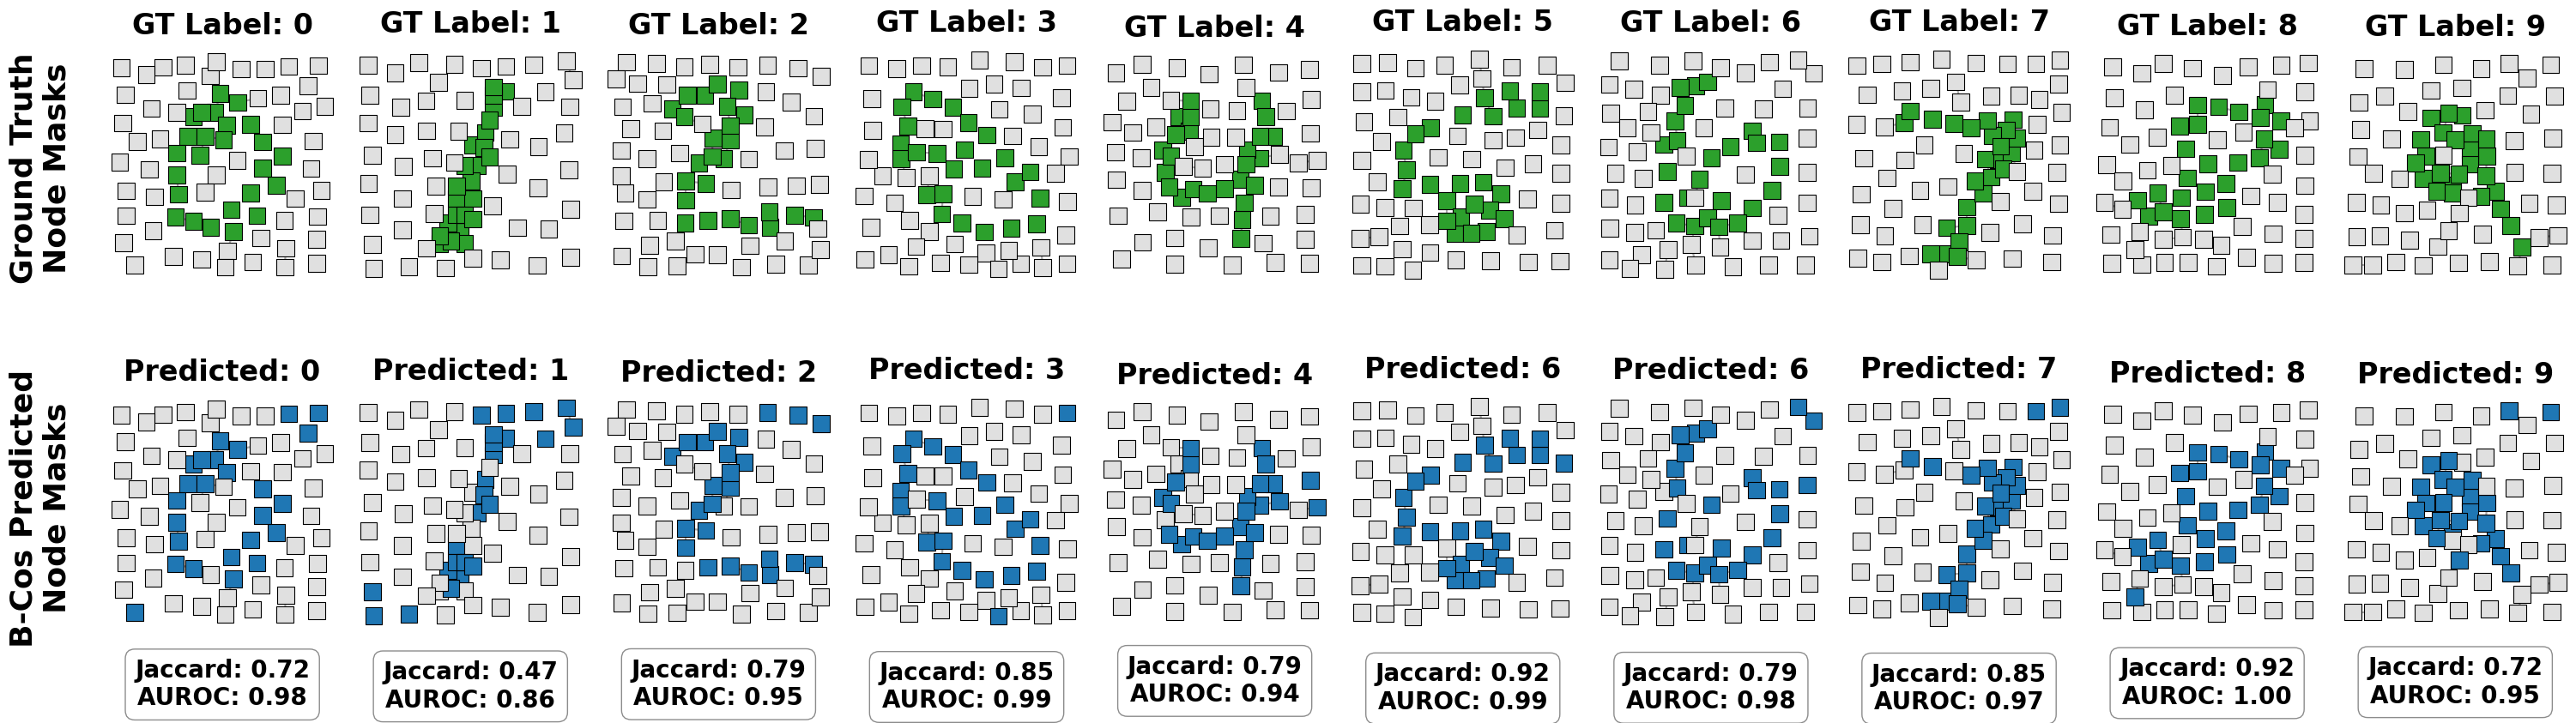

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# Ensure your model is in eval mode
bcos_model.eval()
model_device = next(bcos_model.parameters()).device

# Get the test dataset from your loader
test_dataset = bcos_test_loader.dataset
samples_by_class = {}

# Collect one sample per class
for idx in range(len(test_dataset)):
    data = test_dataset[idx]
    label = int(data.y.item())
    if label not in samples_by_class:
        samples_by_class[label] = data.clone()
    if len(samples_by_class) == dataset_info['num_classes']:
        break

class_labels = sorted(samples_by_class.keys())
num_classes = len(class_labels)

# ---------------------------------------------------------
# Setup Publication-Ready Figure
# ---------------------------------------------------------
fig, axes = plt.subplots(2, num_classes, figsize=(3 * num_classes, 9))

# Tight margins to maximize real estate
fig.subplots_adjust(top=0.88, bottom=0.12, left=0.035, right=0.99, wspace=0.1, hspace=0.45)

# Row Identifiers with HUGE fonts for scaling down in PDFs
fig.text(0.008, 0.72, 'Ground Truth\nNode Masks', fontsize=26, fontweight='bold', va='center', ha='center', rotation=90)
fig.text(0.008, 0.28, 'B-Cos Predicted\nNode Masks', fontsize=26, fontweight='bold', va='center', ha='center', rotation=90)

if num_classes == 1:
    axes = np.array([[axes[0]], [axes[1]]])

# ---------------------------------------------------------
# Plotting Loop
# ---------------------------------------------------------
for col_idx, class_label in enumerate(class_labels):
    graph_data = samples_by_class[class_label].clone().to(model_device)
    batch = torch.zeros(graph_data.x.size(0), dtype=torch.long, device=model_device)

    # 1. Get Model Prediction
    with torch.no_grad():
        logits = bcos_model(graph_data.x, graph_data.edge_index, batch)
        pred_label = int(torch.argmax(logits, dim=-1).item())

    # 2. Get B-Cos Explanation Scores
    node_scores, gt_mask = get_bcos_node_scores(bcos_model, graph_data.clone())
    
    # 3. Calculate Top-K Mask and Metrics
    k = int(gt_mask.sum())
    pred_mask = np.zeros_like(gt_mask)
    if k > 0:
        top_k = np.argsort(node_scores)[-k:]
        pred_mask[top_k] = 1

    auc = float(roc_auc_score(gt_mask, node_scores)) if len(np.unique(gt_mask)) > 1 else float('nan')
    intersection = np.logical_and(pred_mask == 1, gt_mask == 1).sum()
    union = np.logical_or(pred_mask == 1, gt_mask == 1).sum()
    jaccard = float(intersection / union) if union > 0 else 0.0

    # Data for plotting
    x_coords = graph_data.pos[:, 0].detach().cpu().numpy()
    y_coords = graph_data.pos[:, 1].detach().cpu().numpy()
    row, col = graph_data.edge_index
    
    ax_gt = axes[0, col_idx]
    ax_pred = axes[1, col_idx]

    # --- TOP ROW: Ground Truth Plot ---
    for i in range(graph_data.num_edges):
        s = graph_data.pos[row[i]].detach().cpu().numpy()
        e = graph_data.pos[col[i]].detach().cpu().numpy()
        ax_gt.plot([s[0], e[0]], [s[1], e[1]], color='gray', alpha=0.4, linewidth=1.5)
    
    # Draw spaced-out SQUARE nodes
    gt_cmap = plt.cm.colors.ListedColormap(['#e0e0e0', '#2ca02c'])
    ax_gt.scatter(x_coords, y_coords, c=gt_mask, cmap=gt_cmap,
                  marker='s', s=200, edgecolor='black', linewidth=0.8, vmin=0, vmax=1, zorder=5)
    
    ax_gt.invert_yaxis()
    ax_gt.set_aspect('equal')
    ax_gt.axis('off')
    ax_gt.set_title(f'GT Label: {int(graph_data.y.item())}', fontsize=24, fontweight='bold', pad=15)

    # --- BOTTOM ROW: B-Cos Prediction Plot ---
    for i in range(graph_data.num_edges):
        s = graph_data.pos[row[i]].detach().cpu().numpy()
        e = graph_data.pos[col[i]].detach().cpu().numpy()
        ax_pred.plot([s[0], e[0]], [s[1], e[1]], color='gray', alpha=0.4, linewidth=1.5)
    
    # Draw spaced-out SQUARE nodes
    pred_cmap = plt.cm.colors.ListedColormap(['#e0e0e0', '#1f77b4'])
    ax_pred.scatter(x_coords, y_coords, c=pred_mask, cmap=pred_cmap,
                    marker='s', s=200, edgecolor='black', linewidth=0.8, vmin=0, vmax=1, zorder=5)
    
    ax_pred.invert_yaxis()
    ax_pred.set_aspect('equal')
    ax_pred.axis('off')
    ax_pred.set_title(f'Predicted: {pred_label}', fontsize=24, fontweight='bold', pad=15)
    
    # Large metrics text
    ax_pred.text(0.5, -0.15, f'Jaccard: {jaccard:.2f}\nAUROC: {auc:.2f}', 
                 transform=ax_pred.transAxes, ha='center', va='top', 
                 fontsize=20, fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.4'))

# ---------------------------------------------------------
# Save to PDF
# ---------------------------------------------------------
output_filename = 'BCos_MNIST75sp_Explanations.pdf'

# bbox_inches='tight' ensures the rotated text on the left doesn't get clipped
plt.savefig(output_filename, format='pdf', bbox_inches='tight', dpi=300)
print(f"Publication-ready figure saved successfully as: {output_filename}")

plt.show()

## Combined GT vs GSAT vs BCos comparison figure

Saved comparison figure: GSAT_BCos_MNIST_Comparison.pdf


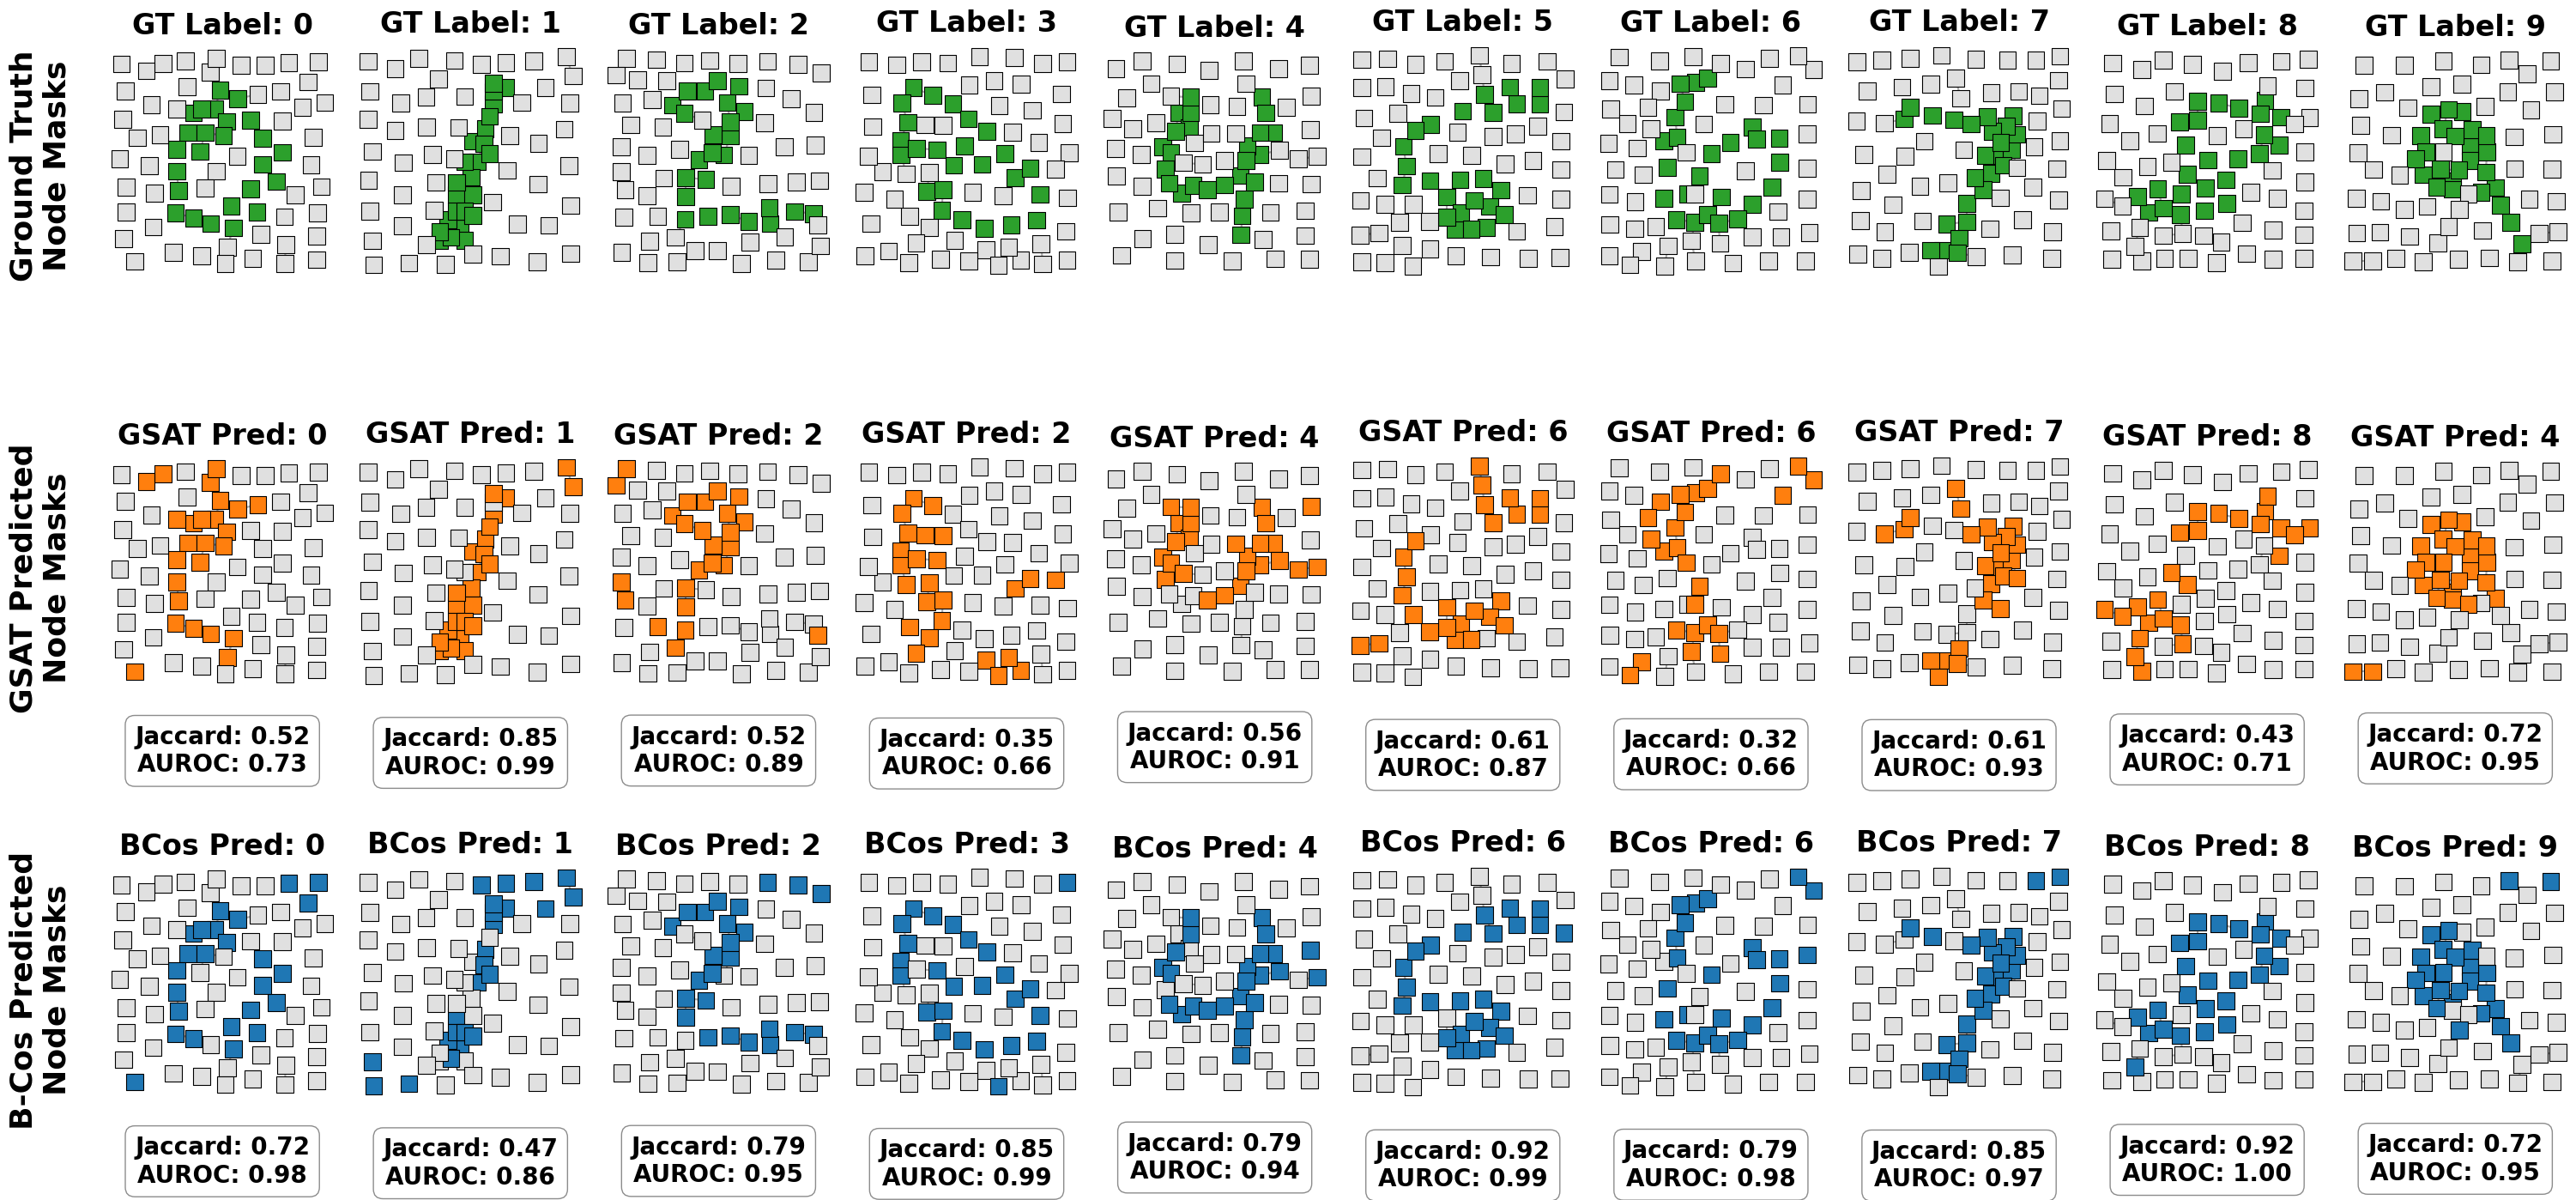

In [25]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# Ensure models are in eval mode
gsat_model.eval()
bcos_model.eval()

gsat_device = next(gsat_model.parameters()).device
bcos_device = next(bcos_model.parameters()).device

# Use the same test dataset for both methods
comparison_dataset = test_dataset

# Collect one sample per class
samples_by_class = {}
for idx in range(len(comparison_dataset)):
    data = comparison_dataset[idx]
    if not (hasattr(data, 'node_mask') or hasattr(data, 'explanation_mask')):
        continue
    label = int(data.y.item())
    if label not in samples_by_class:
        samples_by_class[label] = data.clone()
    if len(samples_by_class) == dataset_info['num_classes']:
        break

class_labels = sorted(samples_by_class.keys())
num_classes = len(class_labels)

# Figure layout: 3 rows (GT, GSAT, BCos) x num_classes columns
fig, axes = plt.subplots(3, num_classes, figsize=(3 * num_classes, 15))
fig.subplots_adjust(top=0.93, bottom=0.08, left=0.035, right=0.99, wspace=0.1, hspace=0.5)

# Row identifiers (match BCos style)
fig.text(0.008, 0.82, 'Ground Truth\nNode Masks', fontsize=26, fontweight='bold', va='center', ha='center', rotation=90)
fig.text(0.008, 0.50, 'GSAT Predicted\nNode Masks', fontsize=26, fontweight='bold', va='center', ha='center', rotation=90)
fig.text(0.008, 0.18, 'B-Cos Predicted\nNode Masks', fontsize=26, fontweight='bold', va='center', ha='center', rotation=90)

if num_classes == 1:
    axes = np.array([[axes[0]], [axes[1]], [axes[2]]])

def _edges_to_node_scores(edge_index, edge_scores, num_nodes):
    node_scores = np.zeros(num_nodes, dtype=float)
    row, col = edge_index
    for i in range(len(row)):
        u = int(row[i])
        v = int(col[i])
        score = float(edge_scores[i])
        if score > node_scores[u]:
            node_scores[u] = score
        if score > node_scores[v]:
            node_scores[v] = score
    return node_scores

for col_idx, class_label in enumerate(class_labels):
    graph_data = samples_by_class[class_label].clone()

    # ----- GT -----
    gt_mask = graph_data.node_mask if hasattr(graph_data, 'node_mask') else graph_data.explanation_mask
    gt_mask = gt_mask.detach().cpu().numpy().astype(int)
    k = int(gt_mask.sum())

    # ----- GSAT -----
    gsat_data = graph_data.clone().to(gsat_device)
    if not hasattr(gsat_data, 'batch') or gsat_data.batch is None:
        gsat_data.batch = torch.zeros(gsat_data.num_nodes, dtype=torch.long, device=gsat_device)
    with torch.no_grad():
        gsat_logits, gsat_edge_mask, _ = gsat_model(gsat_data, training=False)
        gsat_pred_label = int(torch.argmax(gsat_logits, dim=-1).item())
    gsat_node_scores = _edges_to_node_scores(gsat_data.edge_index.cpu().numpy(), gsat_edge_mask.detach().cpu().numpy(), gsat_data.num_nodes)
    gsat_pred_mask = np.zeros_like(gt_mask)
    if k > 0:
        top_k = np.argsort(gsat_node_scores)[-k:]
        gsat_pred_mask[top_k] = 1
    gsat_auc = float(roc_auc_score(gt_mask, gsat_node_scores)) if len(np.unique(gt_mask)) > 1 else float('nan')
    gsat_intersection = np.logical_and(gsat_pred_mask == 1, gt_mask == 1).sum()
    gsat_union = np.logical_or(gsat_pred_mask == 1, gt_mask == 1).sum()
    gsat_jaccard = float(gsat_intersection / gsat_union) if gsat_union > 0 else 0.0

    # ----- BCos -----
    bcos_data = graph_data.clone().to(bcos_device)
    bcos_batch = torch.zeros(bcos_data.x.size(0), dtype=torch.long, device=bcos_device)
    with torch.no_grad():
        bcos_logits = bcos_model(bcos_data.x, bcos_data.edge_index, bcos_batch)
        bcos_pred_label = int(torch.argmax(bcos_logits, dim=-1).item())
    bcos_node_scores, _ = get_bcos_node_scores(bcos_model, bcos_data.clone())
    bcos_pred_mask = np.zeros_like(gt_mask)
    if k > 0:
        top_k = np.argsort(bcos_node_scores)[-k:]
        bcos_pred_mask[top_k] = 1
    bcos_auc = float(roc_auc_score(gt_mask, bcos_node_scores)) if len(np.unique(gt_mask)) > 1 else float('nan')
    bcos_intersection = np.logical_and(bcos_pred_mask == 1, gt_mask == 1).sum()
    bcos_union = np.logical_or(bcos_pred_mask == 1, gt_mask == 1).sum()
    bcos_jaccard = float(bcos_intersection / bcos_union) if bcos_union > 0 else 0.0

    # ----- Plotting -----
    graph_plot = graph_data.to('cpu')
    x_coords = graph_plot.pos[:, 0].detach().cpu().numpy()
    y_coords = graph_plot.pos[:, 1].detach().cpu().numpy()
    row, col = graph_plot.edge_index

    ax_gt = axes[0, col_idx]
    ax_gsat = axes[1, col_idx]
    ax_bcos = axes[2, col_idx]

    for i in range(graph_plot.num_edges):
        s = graph_plot.pos[row[i]].detach().cpu().numpy()
        e = graph_plot.pos[col[i]].detach().cpu().numpy()
        ax_gt.plot([s[0], e[0]], [s[1], e[1]], color='gray', alpha=0.4, linewidth=1.5)
        ax_gsat.plot([s[0], e[0]], [s[1], e[1]], color='gray', alpha=0.4, linewidth=1.5)
        ax_bcos.plot([s[0], e[0]], [s[1], e[1]], color='gray', alpha=0.4, linewidth=1.5)

    gt_cmap = plt.cm.colors.ListedColormap(['#e0e0e0', '#2ca02c'])
    gsat_cmap = plt.cm.colors.ListedColormap(['#e0e0e0', '#ff7f0e'])
    bcos_cmap = plt.cm.colors.ListedColormap(['#e0e0e0', '#1f77b4'])

    ax_gt.scatter(x_coords, y_coords, c=gt_mask, cmap=gt_cmap,
                  marker='s', s=200, edgecolor='black', linewidth=0.8, vmin=0, vmax=1, zorder=5)
    ax_gt.invert_yaxis()
    ax_gt.set_aspect('equal')
    ax_gt.axis('off')
    ax_gt.set_title(f'GT Label: {int(graph_plot.y.item())}', fontsize=24, fontweight='bold', pad=12)

    ax_gsat.scatter(x_coords, y_coords, c=gsat_pred_mask, cmap=gsat_cmap,
                    marker='s', s=200, edgecolor='black', linewidth=0.8, vmin=0, vmax=1, zorder=5)
    ax_gsat.invert_yaxis()
    ax_gsat.set_aspect('equal')
    ax_gsat.axis('off')
    ax_gsat.set_title(f'GSAT Pred: {gsat_pred_label}', fontsize=24, fontweight='bold', pad=12)
    ax_gsat.text(0.5, -0.18, f'Jaccard: {gsat_jaccard:.2f}\nAUROC: {gsat_auc:.2f}',
                 transform=ax_gsat.transAxes, ha='center', va='top',
                 fontsize=20, fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.4'))

    ax_bcos.scatter(x_coords, y_coords, c=bcos_pred_mask, cmap=bcos_cmap,
                    marker='s', s=200, edgecolor='black', linewidth=0.8, vmin=0, vmax=1, zorder=5)
    ax_bcos.invert_yaxis()
    ax_bcos.set_aspect('equal')
    ax_bcos.axis('off')
    ax_bcos.set_title(f'BCos Pred: {bcos_pred_label}', fontsize=24, fontweight='bold', pad=12)
    ax_bcos.text(0.5, -0.18, f'Jaccard: {bcos_jaccard:.2f}\nAUROC: {bcos_auc:.2f}',
                 transform=ax_bcos.transAxes, ha='center', va='top',
                 fontsize=20, fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.4'))

output_filename = 'GSAT_BCos_MNIST_Comparison.pdf'
plt.savefig(output_filename, format='pdf', bbox_inches='tight', dpi=300)
print(f"Saved comparison figure: {output_filename}")
plt.show()